### 2. 함수 해설 — 환경 준비용 도우미 함수


| 함수 | 한 줄 역할 |
|---|---|
| `_is_colab()` | 지금 Colab에서 도는지 확인 |
| `_pip_install(pkg)` | 패키지를 여러 방법으로 설치 시도 |

**핵심 설계 — "실패해도 멈추지 않는다(graceful fallback)"

>  이 셀 끝에서 `USE_GPU` 값을 정합니다. 이 값이 3단계 어조 측정에서 **KcBERT 경로**를 쓸지 **사전 경로**를 쓸지 가릅니다.

In [2]:
# --- 패키지 설치 (T4 GPU 사용) ---
# pandas, numpy, scikit-learn, scipy, matplotlib, torch 는 Colab GPU 런타임에 기본 포함됩니다.
# 추가로 (1) 어조·감성용 transformers (2) 다중비교 보정용 statsmodels 를 준비합니다.
import sys, subprocess

def _is_colab():
    return "google.colab" in sys.modules

def _pip_install(pkg):
    """여러 방식으로 설치 시도 (실패해도 노트북은 계속 진행)."""
    for extra in ([], ["--break-system-packages"]):
        try:
            r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg] + extra,
                               capture_output=True, text=True)
            if r.returncode == 0:
                return True
        except Exception:
            pass
    return False

# (1) transformers (KcBERT 어조·감성용)
try:
    import transformers  # noqa
    print(" transformers 이미 설치됨")
except Exception:
    ok = _pip_install("transformers")
    print("transformers 설치 완료" if ok else
          " transformers 설치 실패 — 어조 측정은 금융 사전으로 폴백합니다.")

# (2) statsmodels (다중비교 보정 FDR-BH)
try:
    import statsmodels  # noqa
    print("statsmodels 이미 설치됨")
except Exception:
    ok = _pip_install("statsmodels")
    print(" statsmodels 설치 완료" if ok else
          " statsmodels 설치 실패 — 다중비교 보정만 건너뜁니다(나머지 정상).")

# (3) 한글 폰트 (그래프용)
if _is_colab():
    subprocess.run(["apt-get", "-y", "install", "fonts-nanum"],
                   capture_output=True, text=True)

# (4) GPU 인식 여부 → USE_GPU 결정
USE_GPU = False
try:
    import torch
    USE_GPU = torch.cuda.is_available()
    if USE_GPU:
        print(f" GPU 인식: {torch.cuda.get_device_name(0)} → 어조 측정에 KcBERT 사용")
    else:
        print(" GPU 미인식 → 어조 측정은 금융 전용 사전(규칙 기반) 사용")
except Exception:
    print(" torch 없음 → 어조 측정은 금융 전용 사전(규칙 기반) 사용")


 transformers 이미 설치됨
statsmodels 이미 설치됨
 GPU 인식: Tesla T4 → 어조 측정에 KcBERT 사용


### 코드 해설 — 그래프 한글 폰트 잡기

그래프에 한글이 깨지지 않도록, **시스템에 실제로 설치된** 나눔폰트 파일을 직접 등록한 뒤 선택

In [3]:
import matplotlib, glob, warnings
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

for _fp in glob.glob("/usr/share/fonts/truetype/nanum/*.ttf"):
    try:
        fm.fontManager.addfont(_fp)
    except Exception:
        pass

_installed = {f.name for f in fm.fontManager.ttflist}
_chosen = None
for cand in ["NanumGothic", "NanumBarunGothic", "Noto Sans CJK KR", "Malgun Gothic", "AppleGothic"]:
    if cand in _installed:
        _chosen = cand
        break

if _chosen:
    matplotlib.rcParams["font.family"] = _chosen
    print(f"그래프 한글 폰트: {_chosen}")
else:
    warnings.filterwarnings("ignore", message="Glyph .* missing from font")
    print("한글 폰트를 찾지 못했습니다. Colab이면 '런타임 → 세션 다시 시작' 후 재실행하세요.")

matplotlib.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지


그래프 한글 폰트: NanumGothic


## 2. 요건 정의 (Requirements)

###  함수 해설 — `Config` (설정값 한곳 모으기)

 난수 seed(재현성), 분석 기준시점 `as_of`(이 날짜 이후 정보 사용 금지), 통계 임계값 등 -> 설정이 흩어져 있으면 나중에 무엇을 바꿨는지 추적이 안 되므로, 한곳에 모으는 것

In [4]:
import numpy as np
import pandas as pd
from dataclasses import dataclass

np.random.seed(2003)  # 재현성 고정

@dataclass
class Config:
    as_of: str = "2025-12-31"          # 분석 기준시점: 이후 정보 사용 금지
    n_topics_grid: tuple = (4, 6, 8)    # 토픽 수 후보 (perplexity로 선택)
    alpha: float = 0.05                 # 유의수준
    mc_method: str = "fdr_bh"           # 다중비교 보정: 벤야미니-호크버그
    spike_z: float = 2.5                # 어조 급변 탐지 임계 z
    psi_retrain: float = 0.25           # 재학습 트리거(참고)
    pipeline_version: str = "v1.0.0-colab"
    dict_version: str = "fin-lex-2026.06"

CFG = Config()
print("기준시점:", CFG.as_of, "| GPU 사용:", USE_GPU, "| 파이프라인:", CFG.pipeline_version)


기준시점: 2025-12-31 | GPU 사용: True | 파이프라인: v1.0.0-colab


## 3. 데이터 수집 · 거버넌스 (Data & Governance)

###  함수 해설 — 실제 기업 자료 수집 + 시점 누출 가드 (이 단계의 심장)

대상 기업은 **네이버(NAVER), 카카오(Kakao), 쿠팡(Coupang)** 세 곳(토스 제외). 각 기업의 공식·허용된 출처에서 문서를 모으되, 모든 문서에 **언제 공개됐는지**(`disclosure_date`)를 함께 기록.

**수집 출처 — 약관·저작권을 지키는 정식 경로만 사용**

| 기업 | 사업보고서/공시 | IR·ESG 보고서 | 뉴스 |
|---|---|---|---|
| 네이버 (NAVER Corp) | DART 전자공시 | 공식 IR·지속가능경영보고서 | BigKinds 등 라이선스 뉴스 |
| 카카오 (Kakao Corp) | DART 전자공시 | 공식 IR·ESG 보고서 | BigKinds 등 라이선스 뉴스 |
| 쿠팡 (Coupang, Inc.) | **미국 SEC** (NYSE 상장, 10-K/8-K) | 공식 IR·ESG 보고서 | BigKinds 등 라이선스 뉴스 |

> ⚠️ 쿠팡은 미국 상장사라 DART가 아니라 **SEC EDGAR** 공시를 사용. 출처가 다르다는 점을 데이터에 표시

| 함수 | 역할 |
|---|---|
| `load_corpus(as_of)` | 폴더의 실수집 파일을 읽어 **누출 가드** 적용 (없으면 라벨드 데모로 폴백) |
| `make_labeled_demo()` | 실수집 파일이 없을 때, **실제 기업명 + 합성 텍스트**로 구조만 보여주는 데모 |

>  데모 폴백은 회사명만 실제(네이버·카카오·쿠팡)이고 **본문은 합성**. 실제 분석이 아님을 `source_type` 컬럼과 화면 표시로 분명히 구분

In [5]:
import os, glob
import pandas as pd
import numpy as np
from dataclasses import dataclass

# =====================================================================
#  ⚙️ 실행 설정 (CFG)
#  - 이 코드에는 API 키가 없습니다(로컬 파일/데모 기반). 지울 키 없음.
#  - 단독 실행을 위해 CFG.as_of(분석 기준 시점)를 정의합니다.
#  - 앞 셀에서 CFG가 이미 있으면 재사용하고, as_of만 없으면 보강합니다.
# =====================================================================
try:
    CFG  # 앞 셀에서 정의돼 있으면 재사용
except NameError:
    @dataclass
    class Config:
        as_of: str = "2025-12-31"   # 분석 기준 시점(이 날짜 이후 문서는 누출 가드로 제외)
        seed: int = 42
    CFG = Config()
else:
    if not hasattr(CFG, "as_of"):
        try:
            CFG.as_of = "2025-12-31"
        except Exception:
            pass  # frozen dataclass 등으로 못 넣으면 아래 폴백 사용

AS_OF = getattr(CFG, "as_of", "2025-12-31")

# ── 대상 기업 레지스트리 (네이버·카카오·쿠팡, 토스 제외) ──
TARGET_COMPANIES = {
    "네이버":  {"legal_name": "NAVER Corp",  "sector": "인터넷플랫폼",
               "disclosure_source": "DART"},        # 국내 상장
    "카카오":  {"legal_name": "Kakao Corp",   "sector": "인터넷플랫폼",
               "disclosure_source": "DART"},        # 국내 상장
    "쿠팡":    {"legal_name": "Coupang, Inc.", "sector": "이커머스",
               "disclosure_source": "SEC"},          # 미국(NYSE) 상장 → SEC
}

# 수동 다운로드 적재 폴더 (출처별). 여기에 내려받은 파일을 넣으면 자동 적재됩니다.
DATA_ROOT = "data/corpus"   # Colab: 좌측 파일창에서 이 경로에 업로드
EXPECTED_COLS = ["company", "doc_type", "disclosure_date", "text"]

def _read_any(path):
    """csv/parquet/json 한 파일을 DataFrame으로."""
    if path.endswith(".parquet"):
        return pd.read_parquet(path)
    if path.endswith(".json") or path.endswith(".jsonl"):
        return pd.read_json(path, lines=path.endswith(".jsonl"))
    return pd.read_csv(path)

def load_real_files(data_root=DATA_ROOT):
    """data/corpus/ 안의 실제 수집 파일을 모두 읽어 통합.
    파일에는 최소 컬럼이 있어야 함: company, doc_type, disclosure_date, text."""
    files = []
    for ext in ("*.csv", "*.parquet", "*.json", "*.jsonl"):
        files += glob.glob(os.path.join(data_root, "**", ext), recursive=True)
    if not files:
        return None
    frames = []
    for fp in sorted(files):
        try:
            d = _read_any(fp)
            miss = [c for c in EXPECTED_COLS if c not in d.columns]
            if miss:
                print(f"  {os.path.basename(fp)}: 누락 컬럼 {miss} → 건너뜀")
                continue
            d["source_file"] = os.path.basename(fp)
            frames.append(d)
        except Exception as e:
            print(f" {os.path.basename(fp)} 읽기 실패({type(e).__name__}) → 건너뜀")
    if not frames:
        return None
    df = pd.concat(frames, ignore_index=True)
    df["source_type"] = "real"     # 실제 수집
    return df

def make_labeled_demo(n_per=16, seed=42):
    """실수집 파일이 없을 때: 실제 기업명 + 합성 텍스트(구조 시연용).
    source_type='demo'로 표시 — 실제 공시 내용 아님."""
    rng = np.random.default_rng(seed)
    hedged = ["성장할 것으로 예상되나 불확실성이 존재한다",
              "일부 위험 요인이 있을 수 있다",
              "시장 상황에 따라 변동 가능성이 있다"]
    confident = ["매출이 확대되어 사상 최대를 기록했다",
                 "목표를 초과 달성했다", "수익성이 크게 개선되었다"]
    esg = ["탄소중립을 추진하며 환경 경영을 강화한다",
           "지속가능성을 우선 가치로 환경 투자를 확대한다"]
    rows, base = [], pd.Timestamp("2024-01-01")
    for comp, meta in TARGET_COMPANIES.items():
        for _ in range(n_per):
            date = base + pd.Timedelta(days=int(rng.integers(0, 900)))
            text = rng.choice(hedged + confident) + ". " + rng.choice(confident)
            dtype = rng.choice(["사업보고서", "ESG", "실적발표", "뉴스"])
            if dtype == "ESG":
                text = rng.choice(esg) + ". " + text
            # 출처 표기: 쿠팡은 SEC, 나머지는 DART
            disc_src = meta["disclosure_source"] if dtype in ("사업보고서",) else "IR/뉴스"
            rows.append(dict(company=comp, legal_name=meta["legal_name"],
                             sector=meta["sector"], doc_type=dtype,
                             disclosure_source=disc_src,
                             disclosure_date=date, text=text))
    df = pd.DataFrame(rows)
    df["source_type"] = "demo"
    return df

def load_corpus(as_of: str) -> pd.DataFrame:
    """실수집 파일 우선 적재 → 없으면 라벨드 데모. 공통으로 누출 가드 적용."""
    df = load_real_files()
    if df is not None:
        print(f"실제 수집 파일 적재: {df['source_file'].nunique()}개 파일, {len(df)}건")
    else:
        df = make_labeled_demo()
        print(" data/corpus/ 에 수집 파일이 없어 '라벨드 데모'로 진행합니다.")
        print("   (회사명만 실제: 네이버·카카오·쿠팡 / 본문은 합성 — 실제 분석 아님)")

    # 대상 기업만 유지 + 메타 보강
    df = df[df["company"].isin(TARGET_COMPANIES)].copy()
    if "sector" not in df or df["sector"].isna().any():
        df["sector"] = df["company"].map(lambda c: TARGET_COMPANIES[c]["sector"])
    if "legal_name" not in df:
        df["legal_name"] = df["company"].map(lambda c: TARGET_COMPANIES[c]["legal_name"])
    df["disclosure_date"] = pd.to_datetime(df["disclosure_date"])
    df.insert(0, "doc_id", range(len(df)))

    # ── 시점 누출 가드 (FR-02): 위반 시 배치 중단 ──
    as_of_ts = pd.to_datetime(as_of)
    before = len(df)
    df = df[df["disclosure_date"] <= as_of_ts].copy()
    assert (df["disclosure_date"] <= as_of_ts).all(), "LEAKAGE: 미래 문서 존재 → 배치 중단"
    print(f"수집 문서: {len(df)}건 (누출 가드로 제외: {before - len(df)}건)")
    return df.reset_index(drop=True)

corpus = load_corpus(AS_OF)
print(corpus.head(3))
print(f"\n기준 시점(as_of): {AS_OF} / 총 {len(corpus)}건 / 기업별:\n{corpus['company'].value_counts()}")


 data/corpus/ 에 수집 파일이 없어 '라벨드 데모'로 진행합니다.
   (회사명만 실제: 네이버·카카오·쿠팡 / 본문은 합성 — 실제 분석 아님)
수집 문서: 40건 (누출 가드로 제외: 8건)
   doc_id company  legal_name  sector doc_type disclosure_source  \
0       0     네이버  NAVER Corp  인터넷플랫폼      ESG             IR/뉴스   
1       2     네이버  NAVER Corp  인터넷플랫폼     실적발표             IR/뉴스   
2       3     네이버  NAVER Corp  인터넷플랫폼     실적발표             IR/뉴스   

  disclosure_date                                              text  \
0      2024-03-21  탄소중립을 추진하며 환경 경영을 강화한다. 목표를 초과 달성했다. 목표를 초과 달성했다   
1      2024-03-25               매출이 확대되어 사상 최대를 기록했다. 수익성이 크게 개선되었다   
2      2025-11-16                        목표를 초과 달성했다. 수익성이 크게 개선되었다   

  source_type  
0        demo  
1        demo  
2        demo  

기준 시점(as_of): 2025-12-31 / 총 40건 / 기업별:
company
카카오    14
네이버    13
쿠팡     13
Name: count, dtype: int64


###  거버넌스 가드(`assert`)와 정제

수집 직후 두 가지를 합니다. 첫째 개인정보(PII) 컬럼이 없는지 확인합니다(개인정보보호법 최소수집 — 사례 C는 문서 단위라 PII가 없어야 정상). 둘째 사례 C 고유의 정제를 합니다: 숫자·표를 본문에서 분리하고, 문장 단위로 자르며, 헤징(완곡·회피) 표현을 태깅할 준비를 합니다.

> 일반 감성사전은 'liability(부채)'·'tax(세금)'를 부정으로 오분류-> 그래서 뒤에서 **금융 전용 사전/KcBERT**를 사용

In [6]:
import re

# 거버넌스 가드: PII 컬럼이 없는지 확인 (개인정보보호법 최소수집)
PII_COLS = {"name", "ssn", "phone", "email", "addr", "주민", "전화", "이메일"}
assert not (set(corpus.columns) & PII_COLS), "PII 컬럼 발견 → 가명·집계 후 재수집 필요"
print(" 거버넌스 가드 통과: PII 컬럼 없음")

# 금융 전용 사전 (실무: Loughran-McDonald 한국어판 등으로 확장)
HEDGING_TERMS = ["수도 있", "예상되나", "불확실", "가능성", "전망되", "다소", "일부", "변동", "보수적", "달려"]
CONFIDENCE_TERMS = ["확대", "최대를 기록", "초과 달성", "개선되었", "견조", "성장할 것", "달성했"]
RISK_TOPIC_TERMS = ["위험", "불확실", "소송", "리콜", "규제", "손상", "하락"]

def split_sentences(text):
    return [s.strip() for s in re.split(r"[.\n]", text) if s.strip()]

def strip_numbers_tables(text):
    return re.sub(r"[0-9０-９%,.\-]+", " ", text)

corpus = corpus.dropna(subset=["text"]).drop_duplicates(subset=["text"]).copy()
corpus["sentences"] = corpus["text"].apply(split_sentences)
corpus["clean_text"] = corpus["text"].apply(strip_numbers_tables)
print(f"정제 후 문서: {len(corpus)}건")


 거버넌스 가드 통과: PII 컬럼 없음
정제 후 문서: 25건


### 수집 현황 — 어떤 기업 정보를 모았나

분석에 들어가기 전에 **"지금 누구의, 어떤 문서를, 얼마나 모았는가"** 를 한눈에 확인합니다. 실무에서 이 표는 두 가지 역할을 합니다. 첫째는 **투명성**으로, 분석 결과를 보는 사람이 어떤 기업이 표본에 들어갔는지 바로 알 수 있어야 합니다. 둘째는 **표본 점검**으로, 특정 기업이나 문서유형에 표본이 쏠려 있으면 비교가 한쪽으로 기울 수 있어 미리 봐 둬야 합니다.

아래 `corpus_overview()` 는

(1) 수집된 기업을 **실제 법인명**과 함께(네이버=NAVER Corp, 카카오=Kakao Corp, 쿠팡=Coupang, Inc.) 보여줌

(2) 기업별 문서 수와 **공시 출처**(DART vs SEC)

(3) 문서유형(사업보고서·ESG·실적발표·뉴스) 구성

(4) 공개시점이 덮는 기간을 정리합니다. 상단에는 데이터가 **실제 수집**인지 **라벨드 데모**인지 배지로 표시해, 보는 사람이 성격을 즉시 구분할 수 있게 합니다. 마지막에 **누출 가드 기준시점(`as_of`)** 을 함께 찍어 모든 문서가 그 이전 공개임을 확인


In [7]:
# === 수집 현황 디스플레이: 어떤 기업 정보를 모았나 ===
def corpus_overview(df, as_of):
    """수집된 기업(실제 법인명·공시출처)·문서유형·기간을 요약(투명성 + 표본 점검)."""
    # 데이터 출처가 실제 수집인지 라벨드 데모인지 판정
    stypes = set(df.get("source_type", pd.Series(["demo"])).unique())
    is_real = stypes == {"real"}
    badge = " 실제 수집 데이터" if is_real else " 라벨드 데모(회사명만 실제·본문 합성)"

    # (1) 기업별: 법인명·업종·공시출처·문서수·기간
    meta_cols = ["company", "legal_name", "sector", "disclosure_source"] \
                if "disclosure_source" in df.columns else ["company", "legal_name", "sector"]
    g = (df.groupby(meta_cols)
           .agg(문서수=("doc_id", "count"),
                최초공개=("disclosure_date", "min"),
                최근공개=("disclosure_date", "max"))
           .reset_index()
           .sort_values("문서수", ascending=False))
    g["최초공개"] = g["최초공개"].dt.date
    g["최근공개"] = g["최근공개"].dt.date
    rename = {"company": "기업", "legal_name": "법인명(공식)",
              "sector": "업종", "disclosure_source": "공시출처"}
    g = g.rename(columns=rename)

    # (2) 기업 × 문서유형 교차표
    pivot = pd.crosstab(df["company"], df["doc_type"])
    pivot["합계"] = pivot.sum(axis=1)

    print("=" * 60)
    print(f" 수집 현황 요약  (기준시점 as_of = {as_of})")
    print(f"   데이터 성격: {badge}")
    print("=" * 60)
    # 어떤 기업을 크롤링했는지 — 실제 법인명으로 명시
    names = " · ".join(f"{c}({TARGET_COMPANIES[c]['legal_name']})" for c in df['company'].unique())
    print(f"· 수집 기업 {df['company'].nunique()}개: {names}")
    print(f"· 총 문서: {len(df)}건   · 업종: {', '.join(sorted(df['sector'].unique()))}")
    print(f"· 공개시점 범위: {df['disclosure_date'].min().date()} ~ {df['disclosure_date'].max().date()}")
    print(f"·  모든 문서가 기준시점({as_of}) 이전 — 누출 가드 통과\n")
    print("[기업별 수집 현황]")
    print(g.to_string(index=False))
    print("\n[기업 × 문서유형 구성]")
    print(pivot.to_string())
    if not is_real:
        print("\n 현재는 라벨드 데모입니다. data/corpus/ 에 DART·SEC·IR/ESG·BigKinds에서")
        print("   내려받은 파일(컬럼: company, doc_type, disclosure_date, text)을 넣으면")
        print("   자동으로 '실제 수집 데이터'로 전환됩니다.")
    return g, pivot

overview_tbl, overview_pivot = corpus_overview(corpus, CFG.as_of)


 수집 현황 요약  (기준시점 as_of = 2025-12-31)
   데이터 성격:  라벨드 데모(회사명만 실제·본문 합성)
· 수집 기업 3개: 네이버(NAVER Corp) · 카카오(Kakao Corp) · 쿠팡(Coupang, Inc.)
· 총 문서: 25건   · 업종: 이커머스, 인터넷플랫폼
· 공개시점 범위: 2024-03-19 ~ 2025-12-09
·  모든 문서가 기준시점(2025-12-31) 이전 — 누출 가드 통과

[기업별 수집 현황]
 기업       법인명(공식)     업종  공시출처  문서수       최초공개       최근공개
네이버    NAVER Corp 인터넷플랫폼 IR/뉴스    9 2024-03-21 2025-12-01
카카오    Kakao Corp 인터넷플랫폼 IR/뉴스    6 2024-06-28 2025-12-09
 쿠팡 Coupang, Inc.   이커머스 IR/뉴스    4 2024-03-19 2025-08-20
네이버    NAVER Corp 인터넷플랫폼  DART    3 2025-02-03 2025-11-13
 쿠팡 Coupang, Inc.   이커머스   SEC    2 2024-09-21 2024-10-16
카카오    Kakao Corp 인터넷플랫폼  DART    1 2025-05-26 2025-05-26

[기업 × 문서유형 구성]
doc_type  ESG  뉴스  사업보고서  실적발표  합계
company                           
네이버         3   2      3     4  12
카카오         2   2      1     2   7
쿠팡          3   0      2     1   6

 현재는 라벨드 데모입니다. data/corpus/ 에 DART·SEC·IR/ESG·BigKinds에서
   내려받은 파일(컬럼: company, doc_type, disclosure_date, text)을 넣으면
   자동으로 '실제 수집 데이터'로 전환

### 그래프 해설 — 수집 현황 막대그래프

위 표를 그림 한 장으로 봄. 왼쪽은 **기업별 문서 수**(표본이 어디에 쏠렸는지), 오른쪽은 **기업 × 문서유형 누적 구성**(어떤 기업이 어떤 문서를 주로 냈는지)을 보여줍니다. 막대 높이가 들쭉날쭉하면 표본 불균형 신호이므로, 검정 결과를 해석할 때 이 그림을 먼저 떠올리기

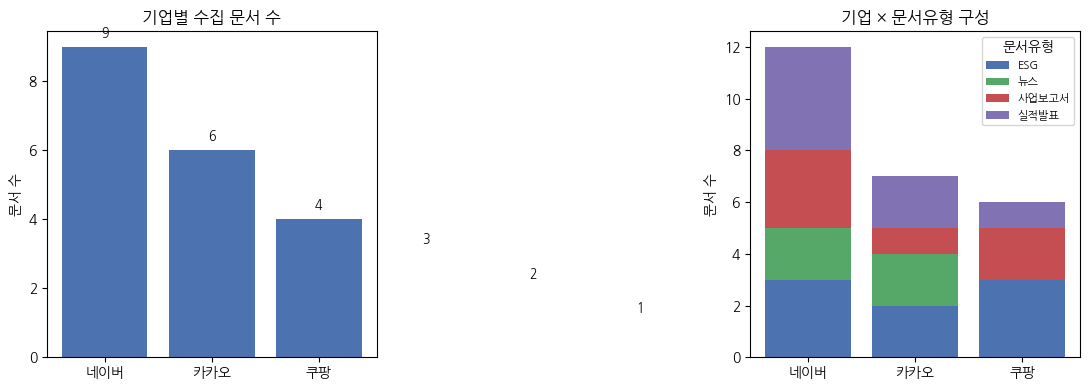

In [8]:
# === 수집 현황 시각화 ===
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# (좌) 기업별 문서 수
axes[0].bar(overview_tbl["기업"], overview_tbl["문서수"], color="#4C72B0")
axes[0].set_title("기업별 수집 문서 수")
axes[0].set_ylabel("문서 수")
for i, v in enumerate(overview_tbl["문서수"]):
    axes[0].text(i, v + 0.3, str(int(v)), ha="center", fontsize=9)

# (우) 기업 × 문서유형 누적 막대
doc_types = [c for c in overview_pivot.columns if c != "합계"]
bottom = np.zeros(len(overview_pivot))
palette = ["#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974"]
for k, dt in enumerate(doc_types):
    axes[1].bar(overview_pivot.index, overview_pivot[dt], bottom=bottom,
                label=dt, color=palette[k % len(palette)])
    bottom += overview_pivot[dt].values
axes[1].set_title("기업 × 문서유형 구성")
axes[1].set_ylabel("문서 수")
axes[1].legend(title="문서유형", fontsize=8)

plt.tight_layout()
plt.show()


## 4. 모델링 — 어조·헤징 측정 + 토픽 (Modeling)

###  함수 해설 — 어조 측정 (GPU면 KcBERT, 아니면 금융 사전)

"경영진이 얼마나 확신하는가 vs 얼마나 발을 빼는가"를 수치화

- **GPU 경로(KcBERT):** 한국어 문맥을 학습한 딥러닝 모델이 문장을 긍정/부정으로 읽습니다. 반어·완곡 표현에 강함 -> 어조 점수를 문장 감성의 평균으로
- **사전 경로(폴백):** 확신어와 헤징어 개수를 세어 (확신 − 회피)를 길이로 나누며 이는 GPU가 없어도 항상 동작함.

두 경로 모두 **헤징 비율**(회피 문장 ÷ 전체 문장)을 함께 계산 -> `USE_GPU` 값에 따라 자동으로 갈립니다.

In [9]:
# 어조·감성 측정 함수 (GPU면 KcBERT, 아니면 금융 사전)
_SENT_PIPE = None
def _get_sentiment_pipe():
    """KcBERT 감성 파이프라인 1회 로드 (GPU)."""
    global _SENT_PIPE
    if _SENT_PIPE is None:
        from transformers import pipeline
        _SENT_PIPE = pipeline(
            "sentiment-analysis",
            model="sangrimlee/bert-base-multilingual-cased-nsmc",
            device=0,  # T4 GPU
        )
    return _SENT_PIPE

def tone_kcbert(texts):
    """KcBERT: 문장 감성을 [-1,+1]로. 어조 점수 = 문장 감성 평균."""
    pipe = _get_sentiment_pipe()
    out = pipe(list(texts), batch_size=16, truncation=True, max_length=128)
    scores = []
    for r in out:
        s = r["score"]
        scores.append(s if r["label"].endswith("1") or r["label"].lower().startswith("pos") else -s)
    return np.array(scores)

def tone_lexicon(text):
    """폴백: (확신어 - 헤징어)/토큰수."""
    toks = text.split(); n = max(len(toks), 1)
    conf = sum(t in text for t in CONFIDENCE_TERMS)
    hed = sum(t in text for t in HEDGING_TERMS)
    return (conf - hed) / n

def hedging_ratio(sents):
    if not sents: return np.nan
    return sum(any(h in s for h in HEDGING_TERMS) for s in sents) / len(sents)

def risk_ratio(sents):
    if not sents: return np.nan
    return sum(any(r in s for r in RISK_TOPIC_TERMS) for s in sents) / len(sents)

# 어조 점수 산출 (경로 자동 선택)
if USE_GPU:
    try:
        corpus["tone"] = tone_kcbert(corpus["clean_text"].tolist())
        print(" 어조 측정: KcBERT(GPU) 경로")
    except Exception as e:
        corpus["tone"] = corpus["clean_text"].apply(tone_lexicon)
        print(f" KcBERT 로딩 실패({type(e).__name__}) → 금융 사전 폴백")
else:
    corpus["tone"] = corpus["clean_text"].apply(tone_lexicon)
    print("어조 측정: 금융 전용 사전 경로")

corpus["hedging_ratio"] = corpus["sentences"].apply(hedging_ratio)
corpus["risk_ratio"] = corpus["sentences"].apply(risk_ratio)
print(corpus.groupby("company")[["tone", "hedging_ratio", "risk_ratio"]].mean().round(4))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/932 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/712M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/711M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

 어조 측정: KcBERT(GPU) 경로
           tone  hedging_ratio  risk_ratio
company                                   
네이버      0.8951         0.1944      0.0833
카카오      0.8503         0.2381      0.1429
쿠팡       0.8824         0.4722      0.1667


###  토픽 수는 perplexity(혼란도)로

LDA는 "주제를 몇 개로 나눌지"를 사람이 정해야 합니다. 너무 적으면 주제가 뭉치고, 너무 많으면 의미 없이 쪼개짐 -> 감이 아니라 **혼란도(perplexity)** 로 보조

| 지표 | 의미 | 해석 |
|---|---|---|
| perplexity | 모델이 데이터를 설명하는 혼란도 | **낮을수록 좋음**. 토픽 수를 바꿔가며 낮아지다 완만해지는 지점 선택 |


In [10]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

def select_n_topics(texts, grid, seed=42):
    cv = CountVectorizer(max_df=0.95, min_df=2)
    X = cv.fit_transform(texts)
    rows, best = [], None
    for k in grid:
        lda = LatentDirichletAllocation(n_components=k, random_state=seed)
        lda.fit(X)
        perp = lda.perplexity(X)
        rows.append({"n_topics": k, "perplexity": round(perp, 2)})
        if best is None or perp < best[1]:
            best = (k, perp)
    return pd.DataFrame(rows), best

perp_table, best = select_n_topics(corpus["clean_text"].tolist(), CFG.n_topics_grid)
print(perp_table.to_string(index=False))
print(f"\n선택된 토픽 수: {best[0]} (perplexity={best[1]:.2f})")
print(" 최종 토픽 타당성은 전문가가 직접 읽어 확인")


 n_topics  perplexity
        4       35.28
        6       35.18
        8       35.29

선택된 토픽 수: 6 (perplexity=35.18)
 최종 토픽 타당성은 전문가가 직접 읽어 확인


## 5. 검증 · 보고서화 (Validation & Reporting)

### 세 검정을 왜 이 단계에 쓰고, 수치를 어떻게 읽나

점수화에서 나온 차이가 **진짜인지 우연인지** 가리는 단계(요건정의서 FR-06).

**① t-검정 / Mann-Whitney (시점 간 어조).** 어조는 연속 숫자라 두 시점의 평균 비교에 t-검정이 기본 -> 분포가 치우치면 순위 기반 **Mann-Whitney**로 대체하므로 둘을 함께 돌리기.

| 지표 | 좋음/해석 | 주의 | 위험 |
|---|---|---|---|
| p-value | <0.001 매우 강함 | 0.05 부근 | ≥0.05 유의 아님(판단 보류) |
| Cohen's d | ≥0.8 큼 | 0.5 중간 | <0.2 미미 |

**② 카이제곱 + Cramér's V (동종업계 위험언어).** "위험 주제 언급함/안 함" 비율을 두 집단에서 비교 → 카이제곱. 크기는 Cramér's V(0.10 약함 / 0.30 중간 / 0.50↑ 강함). 각 칸 기대빈도 5 미만이면 **피셔 정확검정**으로 자동 대체.

**③ Spearman 상관 (그린워싱 단서).** ESG 환경 강조 비중 vs 실측 성과가 함께 움직이는지. 비선형·이상치에 강건한 순위 기반. 상관계수 0.1/0.3/0.5(약/중/강). **음(−)이 강하면 그린워싱 '단서'일 뿐 증명 아님(상관≠인과).**

**④ 검정력 — 사례 C 핵심 함정.** 표본이 작으면 진짜 차이도 "유의 아님"으로 나옴 ->  문서 단위라 표본이 작은 사례 C에서 "유의 아님"은 "차이 없음"이 아니라 **판단 보류**

**⑤ 다중비교 보정.** 여러 검정을 동시에 하면 거짓 양성이 누적 **벤야미니-호크버그(FDR)** 로 보정하고 보정 후 유의 여부를 함께 봄.

In [11]:
from scipy import stats
try:
    from statsmodels.stats.multitest import multipletests
    _HAS_SM = True
except Exception:
    _HAS_SM = False

def cohens_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    if n1 < 2 or n2 < 2: return np.nan
    pooled = np.sqrt(((n1-1)*np.var(g1, ddof=1)+(n2-1)*np.var(g2, ddof=1))/(n1+n2-2))
    return (np.mean(g1)-np.mean(g2))/pooled if pooled else np.nan

_d = lambda d: "큼" if abs(d)>=0.8 else "중간" if abs(d)>=0.5 else "작음" if abs(d)>=0.2 else "미미"
_v = lambda v: "강함" if v>=0.5 else "중간" if v>=0.3 else "약함" if v>=0.1 else "미미"
_r = lambda r: "강함" if abs(r)>=0.5 else "중간" if abs(r)>=0.3 else "약함" if abs(r)>=0.1 else "미미"

def compare_tone_over_time(g1, g2):
    res = {"n1": len(g1), "n2": len(g2)}
    if len(g1)<2 or len(g2)<2:
        res["note"]="표본 부족 → 판단 보류"; return res
    res["welch_p"]=round(stats.ttest_ind(g1,g2,equal_var=False).pvalue,4)
    res["mwu_p"]=round(stats.mannwhitneyu(g1,g2,alternative="two-sided").pvalue,4)
    d=cohens_d(g1,g2); res["cohens_d"]=round(float(d),4); res["effect"]=_d(d)
    if min(len(g1),len(g2))<30:
        res["power_warning"]="소표본: 검정력 낮음 → '유의 아님'은 판단 보류"
    return res

def chisq_sector(table):
    table=np.asarray(table)
    chi2,p,dof,expected=stats.chi2_contingency(table)
    use_fisher=(expected<5).any()
    out={"expected_min":round(float(expected.min()),2),"use_fisher":bool(use_fisher)}
    if use_fisher and table.shape==(2,2):
        _,p=stats.fisher_exact(table); out["test"]="Fisher 정확검정"
    else:
        out["test"]="카이제곱"
    n=table.sum(); v=np.sqrt(chi2/(n*(min(table.shape)-1))) if n else np.nan
    out.update(p=round(float(p),4), cramers_v=round(float(v),4), assoc=_v(v))
    return out

def greenwashing_corr(emphasis, actual):
    if len(emphasis)<3: return {"note":"표본 부족 → 판단 보류"}
    rho,p=stats.spearmanr(emphasis,actual)
    return {"spearman_rho":round(float(rho),4),"strength":_r(rho),
            "p":round(float(p),4),"hint":"음(−)이고 강하면 그린워싱 '단서'(단정 금지)"}

def apply_mc(pvals, method="fdr_bh", alpha=0.05):
    pvals=[p for p in pvals if p is not None and not np.isnan(p)]
    if not pvals or not _HAS_SM: return pd.DataFrame({"p_raw":pvals})
    rej,padj,_,_=multipletests(pvals,alpha=alpha,method=method)
    return pd.DataFrame({"p_raw":np.round(pvals,4),"p_adj":np.round(padj,4),"sig_after":rej})

# 검정 실행
# ① 시점 간 어조: 네이버를 예시 기업으로(전반기 vs 후반기)
FOCAL = "네이버"
sub=corpus[corpus["company"]==FOCAL]; cut=pd.Timestamp("2024-10-01")
early=sub[sub["disclosure_date"]<=cut]["tone"].dropna().values
late =sub[sub["disclosure_date"]> cut]["tone"].dropna().values
r1=compare_tone_over_time(early,late); print(f"① 시점 간 어조({FOCAL}):",r1)

# ② 동종업계 위험언어: 인터넷플랫폼(네이버·카카오) vs 이커머스(쿠팡)
plat=corpus.copy()
plat["is_platform"]=plat["sector"]=="인터넷플랫폼"; plat["m_risk"]=plat["risk_ratio"]>0
r2=chisq_sector(pd.crosstab(plat["is_platform"],plat["m_risk"]).values)
print("② 업종 간 위험언어(플랫폼 vs 이커머스):",r2)

esg=corpus[corpus["doc_type"]=="ESG"].copy(); rng=np.random.default_rng(7)
emph=esg["clean_text"].str.contains("환경|탄소|지속가능").astype(float).values+rng.normal(0,0.1,len(esg))
act=-0.3*emph+rng.normal(0,0.3,len(esg))
r3=greenwashing_corr(emph,act); print("③ ESG 강조-실측 상관:",r3)

print("\n⑤ 다중비교 보정:")
print(apply_mc([r1.get("welch_p"),r2.get("p"),r3.get("p")],CFG.mc_method,CFG.alpha).to_string(index=False))


① 시점 간 어조(네이버): {'n1': 3, 'n2': 9, 'welch_p': np.float64(0.1592), 'mwu_p': np.float64(0.3727), 'cohens_d': 0.5836, 'effect': '중간', 'power_warning': "소표본: 검정력 낮음 → '유의 아님'은 판단 보류"}
② 업종 간 위험언어(플랫폼 vs 이커머스): {'expected_min': 1.44, 'use_fisher': True, 'test': 'Fisher 정확검정', 'p': 0.6061, 'cramers_v': 0.0132, 'assoc': '미미'}
③ ESG 강조-실측 상관: {'spearman_rho': 0.2619, 'strength': '약함', 'p': 0.5309, 'hint': "음(−)이고 강하면 그린워싱 '단서'(단정 금지)"}

⑤ 다중비교 보정:
 p_raw  p_adj  sig_after
0.1592 0.4776      False
0.6061 0.6061      False
0.5309 0.6061      False


###  어조 시계열 + 위험언어 히트맵 (PT의 핵심 두 장)

 **어조 시계열** = 회사별 어조가 분기마다 어디로 가는지(낮을수록 회피적)

 **히트맵** = 어느 회사·문서유형에서 위험언어가 짙은지를 한눈에 보임

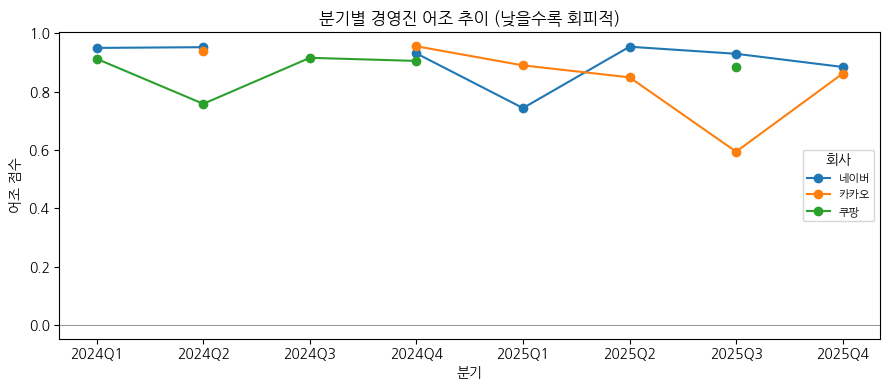

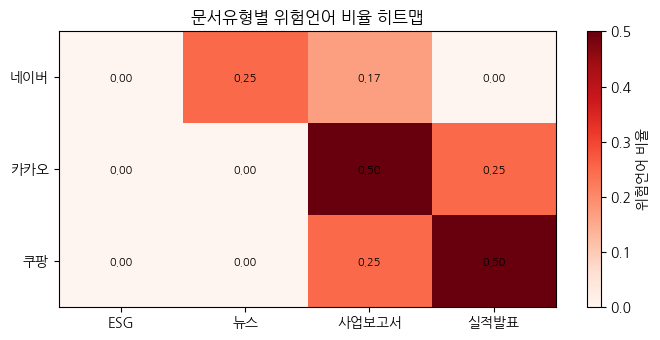

In [12]:
# (1) 어조 시계열
corpus["quarter"]=corpus["disclosure_date"].dt.to_period("Q").astype(str)
tone_ts=corpus.groupby(["quarter","company"])["tone"].mean().unstack()
fig,ax=plt.subplots(figsize=(9,4))
tone_ts.plot(marker="o",ax=ax)
ax.set_title("분기별 경영진 어조 추이 (낮을수록 회피적)")
ax.set_xlabel("분기"); ax.set_ylabel("어조 점수"); ax.axhline(0,color="gray",lw=0.6)
ax.legend(title="회사",fontsize=8); plt.tight_layout(); plt.show()

# (2) 위험언어 히트맵
risk_pivot=corpus.groupby(["company","doc_type"])["risk_ratio"].mean().unstack().fillna(0)
fig,ax=plt.subplots(figsize=(7,3.5))
im=ax.imshow(risk_pivot.values,cmap="Reds",aspect="auto")
ax.set_xticks(range(len(risk_pivot.columns))); ax.set_xticklabels(risk_pivot.columns)
ax.set_yticks(range(len(risk_pivot.index))); ax.set_yticklabels(risk_pivot.index)
ax.set_title("문서유형별 위험언어 비율 히트맵")
for i in range(risk_pivot.shape[0]):
    for j in range(risk_pivot.shape[1]):
        ax.text(j,i,f"{risk_pivot.values[i,j]:.2f}",ha="center",va="center",fontsize=8)
fig.colorbar(im,ax=ax,label="위험언어 비율"); plt.tight_layout(); plt.show()


###  z-score 기반 급증(스파이크) 탐지

어조 시계열에서 평소 범위를 크게 벗어난 급변을 잡아 알립니다. **z-score**는 "평소 평균에서 표준편차 몇 배 떨어졌나" => 절댓값이 임계(2.5)를 넘으면 급변으로 봄.


In [ ]:
def spike_detect(series, z_threshold=2.5):
    if len(series)<3 or series.std(ddof=0)==0:
        return pd.DataFrame(columns=["period","value","z"])
    z=(series-series.mean())/(series.std(ddof=0)+1e-9)
    out=pd.DataFrame({"period":series.index.astype(str),"value":series.round(4).values,"z":z.round(2).values})
    return out[out["z"].abs()>z_threshold]

alerts=[]
for comp,s in corpus.groupby("company"):
    ts=s.groupby(s["disclosure_date"].dt.to_period("Q"))["tone"].mean()
    sp=spike_detect(ts,CFG.spike_z)
    if not sp.empty:
        sp.insert(0,"company",comp); alerts.append(sp)
alerts=pd.concat(alerts) if alerts else pd.DataFrame(columns=["company","period","value","z"])
print("어조 급변 알림 (사람 확인 요청):")
print(alerts.to_string(index=False) if not alerts.empty else "  (임계 초과 없음)")


어조 급변 알림 (사람 확인 요청):
  (임계 초과 없음)


## 6. MLOps · 사후 관리 (Operations)

### 사람 검토 루프 + 시그널 카드 + 재현 메타

자동 산출된 시그널은 **그 자체로 결론이 아닙니다.** RA가 검토해 승인한 것만 의견의 보조 입력으로 (요건정의서 FR-09, 시그널 비결정성). 동시에 어떤 문서·버전·사전으로 산출됐는지 **시그널 카드와 재현 메타**를 남겨 사고 시 역추적(FR-10).

| 함수 | 역할 |
|---|---|
| `human_review()` | 사람이 승인/기각 → approved만 사용 |
| `run_meta` | 재현성 메타(버전·GPU·seed·기준시점) 기록 |

In [14]:
import json, datetime
import pandas as pd

# Ensure 'alerts' is defined, e.g., if the previous cell was not run
try:
    alerts # Check if alerts is already defined
except NameError:
    # If not defined, initialize it as an empty DataFrame as per its definition in the previous cell
    alerts = pd.DataFrame(columns=["company", "period", "value", "z"])

signal_card = {
    "signal_id": f"caseC-{datetime.date.today().isoformat()}",
    "as_of": CFG.as_of, "pipeline_version": CFG.pipeline_version,
    "dict_version": CFG.dict_version, "used_gpu": bool(USE_GPU),
    "n_docs": int(len(corpus)),
    "companies": sorted(corpus["company"].unique().tolist()),
    "source_type": sorted(corpus.get("source_type", pd.Series(["demo"])).unique().tolist()),
    "findings": {"tone_over_time(네이버)": r1, "sector_risk_language": r2,
                 "esg_greenwashing_corr": r3},
    "spike_alerts": alerts.to_dict(orient="records"),
    "review_status": "pending",
    "decision_use": "보조 시그널 (의견 자동 확정 금지)",
    "limits": ["인상관리 가능","상관≠인과","소표본 검정력 한계","시점누출 가드 적용",
               "데모는 회사명만 실제·본문 합성"],
}

def human_review(card, status, reviewer, note=""):
    assert status in ("approved","rejected")
    card.update(review_status=status, reviewer=reviewer, review_note=note,
                reviewed_at=datetime.datetime.now().isoformat(timespec="seconds"))
    return card

signal_card = human_review(signal_card, "approved", "RA_홍길동",
                           "네이버 어조 변화 신호 확인, 보수적 관점 보조 입력으로 채택(데모)")

run_meta = {"run_at": datetime.datetime.now().isoformat(timespec="seconds"),
            "pipeline_version": CFG.pipeline_version, "seed": 42,
            "used_gpu": bool(USE_GPU), "as_of": CFG.as_of, "n_docs": int(len(corpus))}
print(json.dumps(signal_card, ensure_ascii=False, indent=2, default=str)[:900])
print("\n[재현 메타]", json.dumps(run_meta, ensure_ascii=False))

{
  "signal_id": "caseC-2026-06-20",
  "as_of": "2025-12-31",
  "pipeline_version": "v1.0.0-colab",
  "dict_version": "fin-lex-2026.06",
  "used_gpu": true,
  "n_docs": 25,
  "companies": [
    "네이버",
    "카카오",
    "쿠팡"
  ],
  "source_type": [
    "demo"
  ],
  "findings": {
    "tone_over_time(네이버)": {
      "n1": 3,
      "n2": 9,
      "welch_p": 0.1592,
      "mwu_p": 0.3727,
      "cohens_d": 0.5836,
      "effect": "중간",
      "power_warning": "소표본: 검정력 낮음 → '유의 아님'은 판단 보류"
    },
    "sector_risk_language": {
      "expected_min": 1.44,
      "use_fisher": true,
      "test": "Fisher 정확검정",
      "p": 0.6061,
      "cramers_v": 0.0132,
      "assoc": "미미"
    },
    "esg_greenwashing_corr": {
      "spearman_rho": 0.2619,
      "strength": "약함",
      "p": 0.5309,
      "hint": "음(−)이고 강하면 그린워싱 '단서'(단정 금지)"
    }
  },
  "spike_alerts": [],
  "review_status": "approved",
  "decisi

[재현 메타] {"run_at": "2026-06-20T10:31:43", "pipeline_version": "v1.0.0-colab", "seed": 42, "used_gp

## 7. 기만 자가감사 (Profile §2.8)

`deception-auditor` 5×7×3 분류 기준으로 본 노트북을 최종 점검한 결과

| 잠재 사례 | ① 유형 | ② 대상 | ③ 메커니즘 | 검토 결과 |
|---|---|---|---|---|
| 데모 합성 데이터를 실측처럼 오인 | D·P2 | 세계사실 | 날조 위험 | 상단·각 단계에 "합성·실측 아님" 명시, 신호는 학습용 의도 삽입임을 밝힘 |
| GPU/KcBERT가 항상 더 정확하다는 과신 | D·P6 | 능력 | 화용적 왜곡 | GPU는 반어·완곡 처리 개선일 뿐, 폴백 사전과 동일하게 인과 단정 금지 |
| 자동 시그널을 결정처럼 사용 | D·P5 | 능력·약속 | 화용적 왜곡 | 사람 검토 루프 강제, `decision_use`에 자동 확정 금지 명시 |
| 소표본 "유의 아님"을 "차이 없음"으로 오보 | U·P1 | 세계사실 | 누락 | `power_warning`·판단 보류를 검정 함수에 내장 |
| ESG 음의 상관을 그린워싱으로 단정 | D·P5 | 추론 | 화용적 왜곡 | `hint`에 "단서·단정 금지", 상관≠인과 명시 |
| 시점 누출 미점검 | H/U·P4 | 능력·약속 | 누락 | 누출 가드 `assert`로 강제, 위반 시 배치 중단 |

**한계 명시:** 본 노트북은 요건정의서 구현 예시이며 실측 결과가 아니다. `load_corpus`를 실데이터로 교체해야 실무 산출이 된다. GPU 경로는 정확도 향상이 아니라 표현 처리 개선이며 통계 임계값은 경험칙이다. Tier 3 검출 없음.